In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 12
       }

plt.rcParams['axes.grid'] = True
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=12) 
matplotlib.rc('ytick', labelsize=12) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
    
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def plot_fig(i, control):
    lines = 2
    height = lines * 3
    fig, axes = plt.subplots(lines,2, figsize=(18, height))
    axes[0,i].plot(aln.t, control[0,0,:], label="control exc")
    axes[0,i+1].plot(aln.t, control[0,1,:], label="control inh")
    axes[1,i].plot(aln.t, aln.state["rates_exc"][0,:], label="rates exc")
    axes[1,i+1].plot(aln.t, aln.state["rates_inh"][0,:], label="rates inh")
    
    """
    axes[2,i].plot(aln.t, aln.state["mufe"][0,:], label="mufe")
    axes[2,i+1].plot(aln.t, aln.state["mufi"][0,:], label="mufi")
    #axes[3,i].plot(aln.t, aln.state["IA"][0,:], label="IA")

    axes[4,i].plot(aln.t, aln.state["seem"][0,:], label="seem")
    axes[3,i].plot(aln.t, aln.state["seim"][0,:], label="seim")
    axes[4,i+1].plot(aln.t, aln.state["siem"][0,:], label="siem")
    axes[3,i+1].plot(aln.t, aln.state["siim"][0,:], label="siim")

    axes[5,i].plot(aln.t, aln.state["seev"][0,:], label="seev")
    axes[5,i+1].plot(aln.t, aln.state["seiv"][0,:], label="seiv")
    axes[6,i].plot(aln.t, aln.state["siev"][0,:], label="siev")
    axes[6,i+1].plot(aln.t, aln.state["siiv"][0,:], label="siiv")

    #axes[6,i].plot(aln.t, aln.state["mue_ou"][0,:], label="mue_ou")
    #axes[6,i+1].plot(aln.t, aln.state["mui_ou"][0,:], label="mui_ou")

    axes[7,i].plot(aln.t, aln.state["sigmae_f"][0,:], label="sigma_e")
    axes[7,i+1].plot(aln.t, aln.state["sigmai_f"][0,:], label="sigma_i")
    #axes[8,i].plot(aln.t, aln.state["Vmean_exc"][0,:], label="V_mean")
    #axes[9,i].plot(aln.t, aln.state["tau_exc"][0,:], label="tau_exc")
    #axes[9,i+1].plot(aln.t, aln.state["tau_inh"][0,:], label="tau_inh")
    """

    for k in range(lines):
        for j in range(2):
            #if ((k,j) != (3,1) and (k,j) != (8,1)):
            axes[k,j].legend()

    plt.tight_layout()
    
def plot_dif(diff_):
    fig, axes = plt.subplots(1,2, figsize=(18, 3))
    axes[0].plot(aln.t, diff_[0,:], label="difference in exc rate")
    axes[1].plot(aln.t, diff_[1,:], label="difference in inh rate")

    for j in range(2):
        axes[j].legend()

    plt.tight_layout()
    
def plot_phi(phi):
    lines = 9
    time = np.arange(0, dur+aln.params.dt, aln.params.dt)
    
    fig, axes = plt.subplots(lines,2, figsize=(18, 26))
    
    axes[0,0].plot(time, phi[0,0,:], label="phi0 - adjoint exc rate")
    axes[0,1].plot(time, phi[0,1,:], label="phi1 - adjoint inh rate")
    
    axes[1,0].plot(time, phi[0,2,:], label="phi2 - adjoint mufe")
    axes[1,1].plot(time, phi[0,3,:], label="phi3 - adjoint mufi")
    
    axes[2,0].plot(time, phi[0,6,:], label="phi6 - adjoint seim")
    axes[2,1].plot(time, phi[0,8,:], label="phi8 - adjoint siim")
    
    axes[3,0].plot(time, phi[0,4,:], label="phi4 - adjoint IA")
    axes[3,1].plot(time, phi[0,17,:], label="phi17 - adjoint V")
    
    axes[4,0].plot(time, phi[0,5,:], label="phi6 - adjoint seem")
    axes[4,1].plot(time, phi[0,7,:], label="phi8 - adjoint siem")
    
    axes[5,0].plot(time, phi[0,9,:], label="phi9 - adjoint seev")
    axes[5,0].plot(time, phi[0,10,:], label="phi10 - adjoint seiv")
    axes[5,1].plot(time, phi[0,11,:], label="phi11 - adjoint siev")
    axes[5,1].plot(time, phi[0,12,:], label="phi12 - adjoint siiv")
    
    axes[6,0].plot(time, phi[0,13,:], label="phi13 - adjoint mue ou")
    axes[6,1].plot(time, phi[0,14,:], label="phi14 - adjoint mui ou")
    
    axes[7,0].plot(time, phi[0,15,:], label="phi15 - adjoint sigma e")
    axes[7,1].plot(time, phi[0,16,:], label="phi16 - adjoint sigma i")
    
    axes[8,0].plot(time, phi[0,18,:], label="phi18 - adjoint tau e")
    axes[8,1].plot(time, phi[0,19,:], label="phi19 - adjoint tau i")

    for k in range(lines):
        for j in range(2):
            axes[k,j].legend()

    plt.tight_layout()

def diff_control(diff_):
    d_int = 0.
    for n in range(diff_.shape[0]):
        for v in range(diff_.shape[1]):
            for t in range(diff_.shape[2]):
                d_int += np.abs(diff_[n,v,t]) * aln.params.dt
    return d_int
            
def setparams():
    
    aln.params.mue_ext_mean = 0.
    aln.params.mui_ext_mean = 0.
    
    aln.params.sigmae_ext = 1.5
    aln.params.sigmai_ext = 1.5
    
    aln.params.ext_exc_current = 0.
    aln.params.ext_inh_current = 0.

    # NO ADAPTATION
    aln.params.IA_init = np.array([0.])
    aln.params.a = 0.
    aln.params.b = 0.
    
    aln.params.di = 0.0
    aln.params.de = 0.0
    aln.params.signalV = 0.
    
def set_init(init_v_):
    init_vars = aln.init_vars
    for i in range(len(init_vars)):
        if aln.params[init_vars[i]].size == 1:
            aln.params[init_vars[i]][0] = init_v_[i]
        else:
            aln.params[init_vars[i]][0,-1] = init_v_[i]
    
rates_exc_init = np.array( [[25. ]] )
rates_inh_init = np.array( [[25. ]] )
mufe_init = np.array( [[1. ]] )  # mV/ms
mufi_init = np.array( [[1. ]] )  # mV/ms
IA_init = np.array( [[0. ]] )  # pA
seem_init = np.array( [[0.0 * 0.5 ]] )
seim_init = np.array( [[0.0 * 0.5 ]] )   
seev_init = np.array( [[0.00 * 0.5 ]] )
seiv_init = np.array( [[0.00 * 0.5 ]] )
siim_init = np.array( [[0.0 * 0.5 ]] )
siem_init = np.array( [[0.0 * 0.5 ]] )
siiv_init = np.array( [[0.00 * 0.5 ]] )
siev_init = np.array( [[0.00 * 0.5 ]] )
mue_ou = np.array( [[0. ]] )
mui_ou = np.array( [[0. ]] )

initvars = np.array( [
rates_exc_init,
rates_inh_init,
mufe_init,
mufi_init,
IA_init,
seem_init ,
seim_init,
seev_init,
seiv_init,
siim_init,
siem_init,
siiv_init,
siev_init,
mue_ou,
mui_ou
    ])

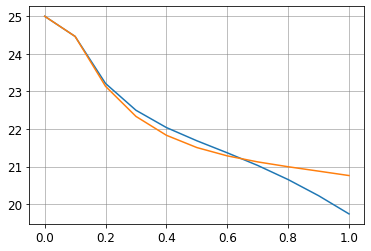

In [8]:
aln = ALNModel()
setparams()
set_init(initvars)

dur = 1.
aln.params['duration'] = dur

control0 = aln.getZeroControl()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

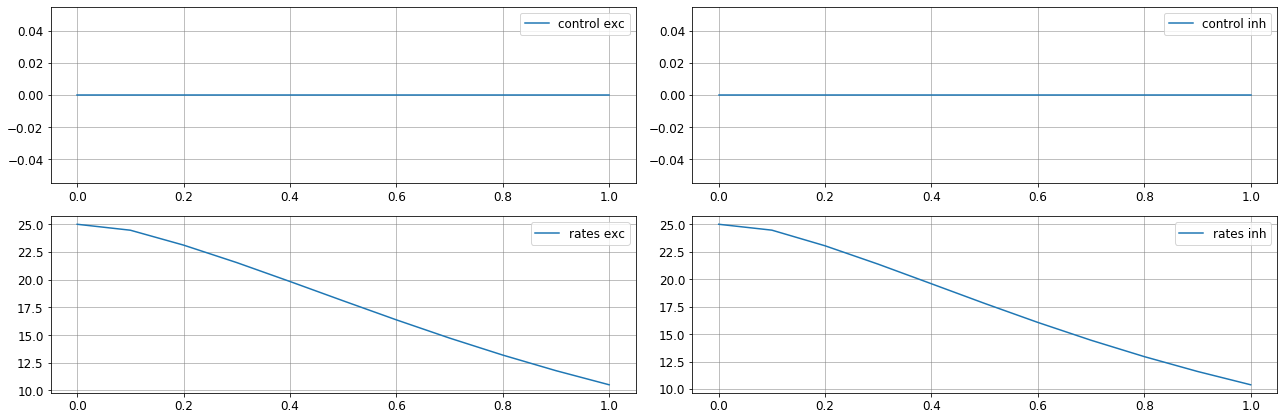

In [35]:
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)
setparams()

aln.params.de = 0.
aln.params.di = 0.2

aln.params.cee = 0.   #0.3
aln.params.cie = 0.   #0.3
aln.params.cei = 0.5  #0.5
aln.params.cii = 0.5  #0.5

aln.params.Jee_max = 1e-20   #2.43
aln.params.Jie_max = 1e-20   #2.60
aln.params.Jei_max = -3.3
aln.params.Jii_max = -1.64
    
aln.run(control=control1)
plot_fig(0, control1)
rates0 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

### Apply control in system with inh $\rightarrow$ inh and inh $\rightarrow$ exc delay

- inhibitory control in timestep 0 and after timestep 6 does not have impact on excitatory rate

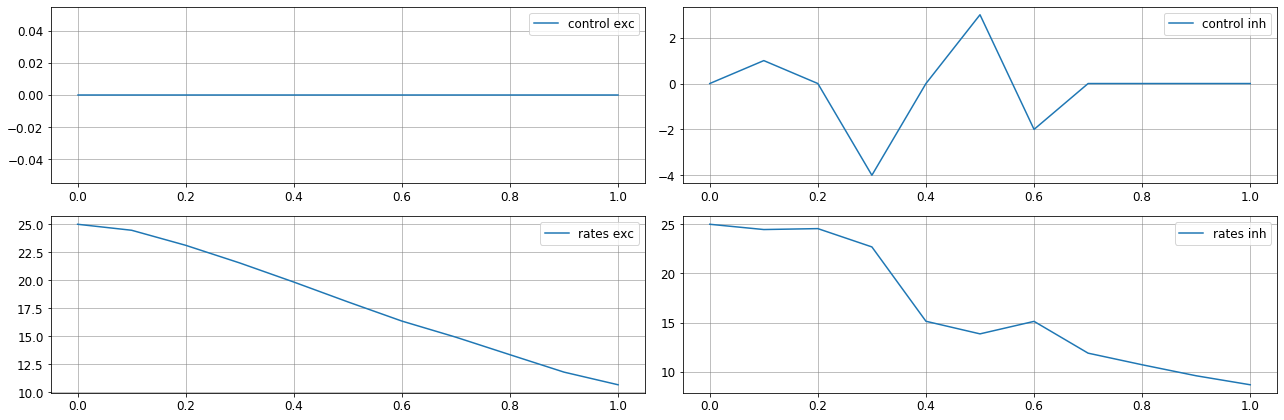

In [36]:
control1 = aln.getZeroControl()
control1[0,1,3] -= 4.
control1[0,1,1] += 1.
control1[0,1,5] += 3.
control1[0,1,6] -= 2.
#control1[0,1,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))


aln.run(control=control1)
plot_fig(0, control1)
plt.savefig("inh_control.pdf")

rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

[ 0.      0.      0.      0.      0.     -0.0302 -0.0275  0.1765  0.1438
 -0.0048  0.1385]


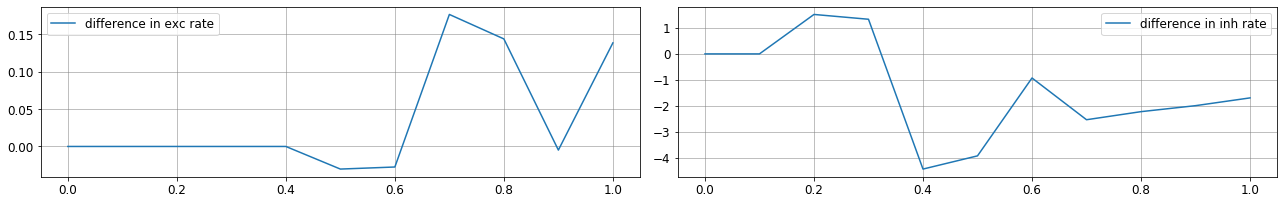

In [37]:
diff = rates1 - rates0
plot_dif(diff)
plt.savefig("diff.pdf")
print(diff[0,:])

In [42]:
max_cntrl = 50. * 5.
start_step = 100.
tol = 1e-30

cost_params = [1.0, 0.0, 0.0]
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()

max_it = 500
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [0])

ERROR:root:Not possible to set up initial conditions without sufficient simulation time before control


set cost params
True 2
RUN  0 , total integrated cost =  0.0036363893831726384
RUN  1 , total integrated cost =  0.0018157457727403662
too small start step, increase to  10000.0
RUN  2 , total integrated cost =  0.00028862231938220004
RUN  3 , total integrated cost =  0.00022048292943143384
RUN  4 , total integrated cost =  0.00018433905659192402
RUN  5 , total integrated cost =  0.0001240568774952625
RUN  6 , total integrated cost =  0.0001142557725505517
too small start step, increase to  10000.0
RUN  7 , total integrated cost =  6.150606614844323e-05
RUN  8 , total integrated cost =  4.263355274213625e-05
too small start step, increase to  10000.0
RUN  9 , total integrated cost =  2.57851362918684e-05
RUN  10 , total integrated cost =  1.7011087022793025e-05
RUN  11 , total integrated cost =  1.5372401396510686e-05
RUN  12 , total integrated cost =  1.2931685061336657e-05
RUN  13 , total integrated cost =  1.2044778462132279e-05
RUN  14 , total integrated cost =  9.508897335543657e-

too small start step, increase to  10000.0
RUN  130 , total integrated cost =  3.3144449575334546e-14
RUN  131 , total integrated cost =  2.1598667286880013e-14
too small start step, increase to  10000.0
RUN  132 , total integrated cost =  2.0238203431513086e-14
RUN  133 , total integrated cost =  1.8815701509411568e-14
RUN  134 , total integrated cost =  1.7837233502500284e-14
RUN  135 , total integrated cost =  1.680885151408794e-14
RUN  136 , total integrated cost =  1.6173841129304938e-14
RUN  137 , total integrated cost =  1.5430292109134086e-14
RUN  138 , total integrated cost =  1.489534788021089e-14
RUN  139 , total integrated cost =  1.4244005347172733e-14
RUN  140 , total integrated cost =  1.3744321513896386e-14
RUN  141 , total integrated cost =  1.3134909550867813e-14
RUN  142 , total integrated cost =  1.2640043018600042e-14
RUN  143 , total integrated cost =  1.1908274777407817e-14
RUN  144 , total integrated cost =  1.1292014038663279e-14
too small start step, increase 

too small start step, increase to  10000.0
RUN  252 , total integrated cost =  4.338886972316929e-20
RUN  253 , total integrated cost =  3.144392608343622e-20
too small start step, increase to  10000.0
RUN  254 , total integrated cost =  2.2120781439263617e-20
RUN  255 , total integrated cost =  1.56589064942865e-20
too small start step, increase to  10000.0
RUN  256 , total integrated cost =  1.4468024818114684e-20
RUN  257 , total integrated cost =  1.3335402533282017e-20
RUN  258 , total integrated cost =  1.2707373084744175e-20
RUN  259 , total integrated cost =  1.1993667398305727e-20
RUN  260 , total integrated cost =  1.1533749801694299e-20
RUN  261 , total integrated cost =  1.098288560656492e-20
RUN  262 , total integrated cost =  1.0587404944062381e-20
RUN  263 , total integrated cost =  1.0121540502162006e-20
RUN  264 , total integrated cost =  9.767446688204764e-21
RUN  265 , total integrated cost =  9.330422128992424e-21
RUN  266 , total integrated cost =  8.98588596522508

too small start step, increase to  10000.0
RUN  375 , total integrated cost =  2.4975336259297236e-28
RUN  376 , total integrated cost =  1.2479779520596408e-28
RUN  377 , total integrated cost =  1.1044052673094165e-28
RUN  378 , total integrated cost =  1.0318300640290835e-28
RUN  379 , total integrated cost =  1.0097419586828951e-28
test control change smaller than tolerance, return zero step
RUN  380 , total integrated cost =  1.0097419586828951e-28
Control only changes marginally.
Improved over  380  iterations by  100.0  percent.
max value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([2], dtype=int64)) 1.4305902000487997e-15
min value of final gradient at index =  (array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64)) -6.357283670642365e-16


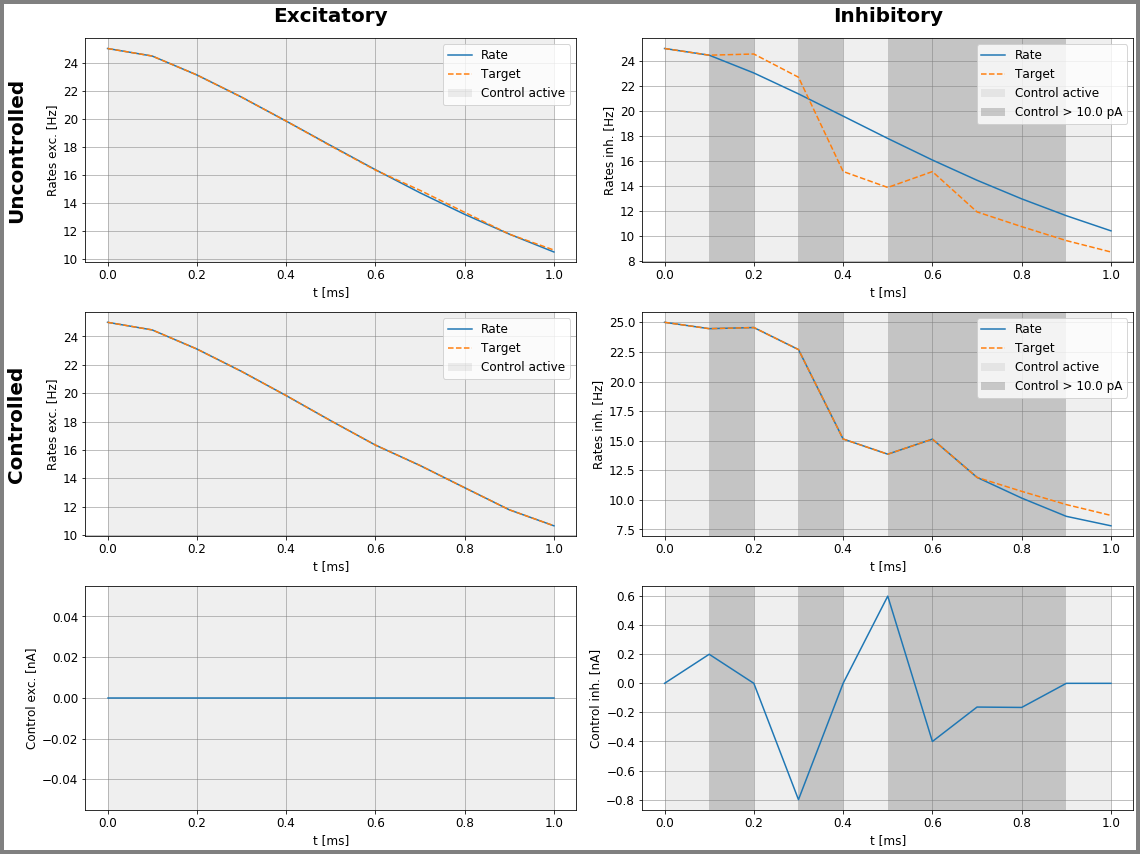

In [43]:
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_inh.pdf')

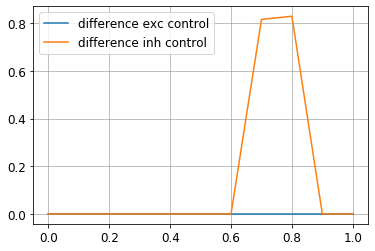

runtime =  0.0
control difference =  0.1644875118335817


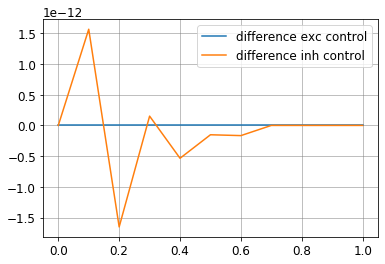

In [44]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

print("runtime = ", runtime[-1])
d_int = diff_control(cDiff)
print("control difference = ", d_int)

cDiff[0,1,7:] = 0.
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

### For excitatory control input only

max delay =  0


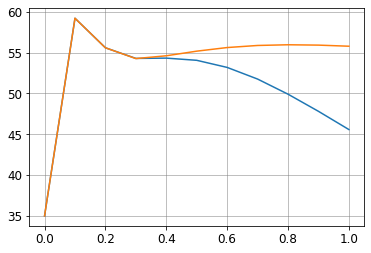

In [462]:
aln = ALNModel()
setparams()
set_init(initvars)
aln.params['duration'] = 1.

control0 = aln.getZeroControl()
#control0 = step_control(maxI_ = 1.)

maxDelay = aln.getMaxDelay()
print("max delay = ", maxDelay)

aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

[35.         59.21274616 55.596433   54.29251745 54.32843987 54.0599205
 53.18944733 51.76301918 49.91022479 44.80662342 42.97043573]
[35.         59.21274616 55.59188139 54.27301682 54.61441869 55.18057563
 55.62309066 55.87812338 55.96401521 55.92051272 55.78592652]


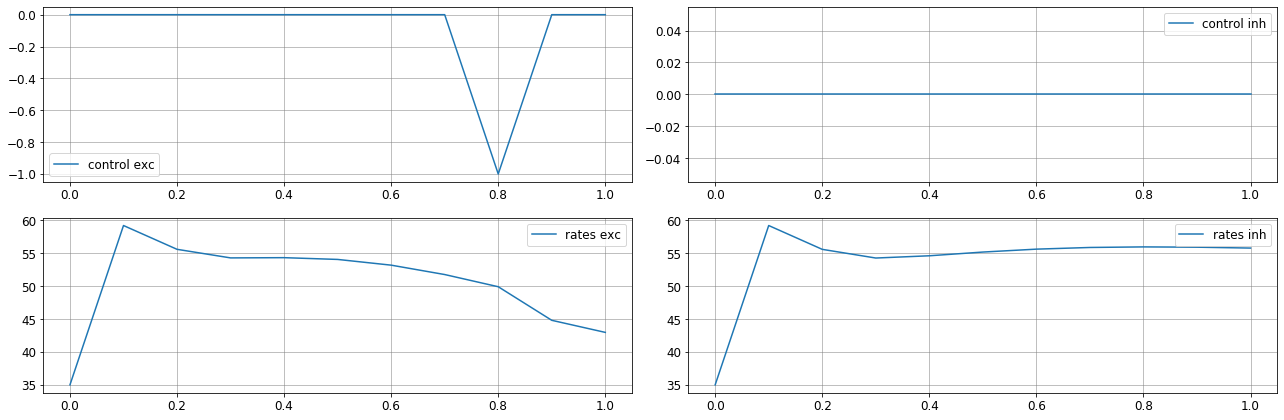

In [492]:
dur = 1.
aln.params.duration = dur
aln.params.de = 0.0
aln.params.di = 0.0

target = aln.getZeroTarget()
control1 = aln.getZeroControl()

set_init(initvars)

control1 = aln.getZeroControl()
#control1[0,0,1] -= 1.
#control1[0,0,3] += 1.
#control1[0,0,5] -= 1.
#control1[0,0,7] += 1.
control1[0,0,8] -= 1.
#control1[0,0,:] += np.cos(6.*np.arange(0,dur+aln.params.dt,aln.params.dt))

#aln.params.de = 0.2

aln.run(control=control1)

target[:,0,:] = aln.state["rates_exc"][0,:]
target[:,1,:] = aln.state["rates_inh"][0,:]

plot_fig(0, control1)
plt.savefig("exc_control_no_delay.pdf")
rates1 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])

[35.         59.21274616 55.596433   54.29251745 54.32843987 54.0599205
 53.18944733 51.76301918 49.91022479 47.81037938 45.57777361]
[35.         59.21274616 55.59188139 54.27301682 54.61441869 55.18057563
 55.62309066 55.87812338 55.96401521 55.92051272 55.7859217 ]


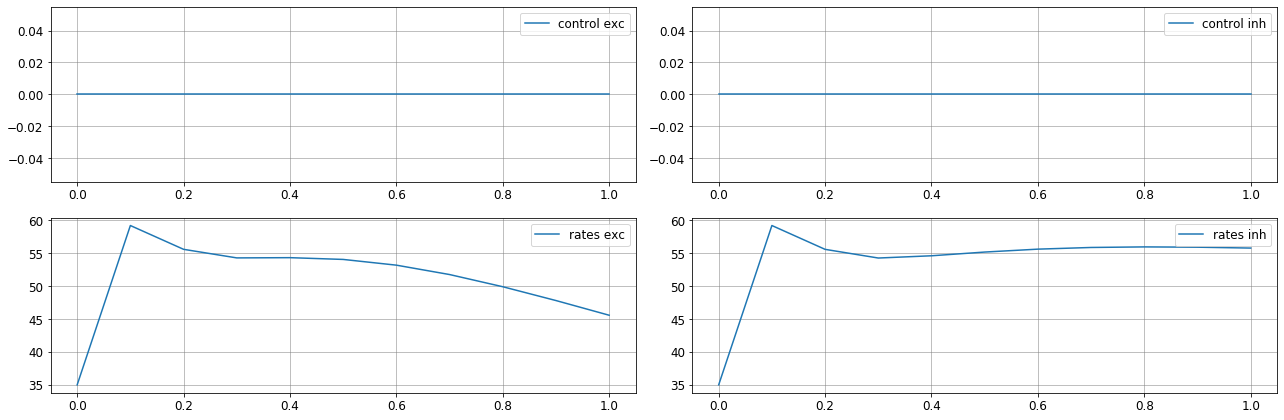

In [494]:
#aln.params.de = 0.2
set_init(initvars)
cntrl = aln.getZeroControl()
aln.run(control=cntrl)

rates2 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )
print(aln.state["rates_exc"][0,:])
print(aln.state["rates_inh"][0,:])
plot_fig(0, cntrl)
plt.savefig("exc_control_delay.pdf")

#target[:,0,:] = aln.state["rates_exc"][0,:]
#target[:,1,:] = aln.state["rates_inh"][0,:]

(2, 11)
[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.         -3.00375595 -2.60733788]


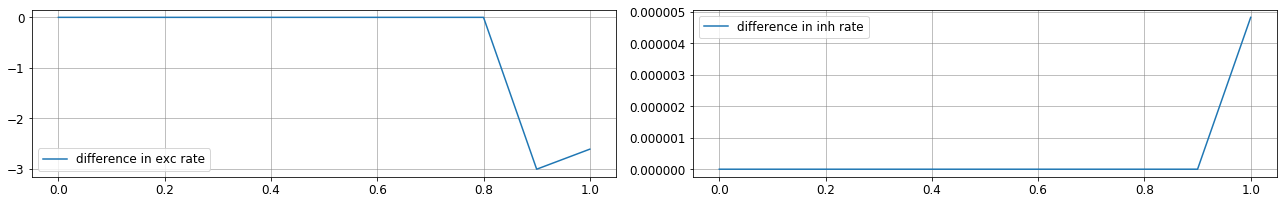

In [495]:
diff = rates1 - rates2
print(diff.shape)
plot_dif(diff)
plt.savefig("diff_exc.pdf")
print(diff[0,:])

In [508]:
max_cntrl = 50. * 5.
start_step = 1e3
cost_params = [1.0, 0.0, 0.0]

#aln.params.di = 0.0

cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = aln.getZeroControl()

max_it = 100
set_init(initvars)

A1_bestControl, A1_bestState, A1_cost, runtime = aln.A1(control2, target, c_scheme, u_mat,
        u_scheme, max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        variables_ = [1])

err = False
for c in range(len(A1_cost)-1):
    if A1_cost[c] < A1_cost[c+1]:
        print("ERROR in index ", c)
        err = True
        break
if not err:
    print("cost decreases throughout computation")

set cost params
True 0
RUN  0 , total integrated cost =  1.162913337862592e-12
RUN  1 , total integrated cost =  7.767613042126656e-13
RUN  2 , total integrated cost =  6.642869538773147e-13
RUN  3 , total integrated cost =  5.859276498132149e-13
RUN  4 , total integrated cost =  4.782335557037573e-13
RUN  5 , total integrated cost =  4.217156311017318e-13
RUN  6 , total integrated cost =  4.0387099710174406e-13
RUN  7 , total integrated cost =  3.9006882883030885e-13
RUN  8 , total integrated cost =  3.826622964692288e-13
RUN  9 , total integrated cost =  3.7546656645857647e-13
RUN  10 , total integrated cost =  3.664209730542012e-13
RUN  11 , total integrated cost =  3.5884009246962606e-13
RUN  12 , total integrated cost =  3.531238622170053e-13
RUN  13 , total integrated cost =  3.480962034528841e-13
RUN  14 , total integrated cost =  3.4134383438335135e-13
RUN  15 , total integrated cost =  3.3511196742427535e-13
RUN  16 , total integrated cost =  3.307767239485994e-13
RUN  17 , to

[ 0.00000000e+00 -3.65868289e-07 -4.84333007e-06  3.91516008e-06
  1.90955975e-05  3.06825256e-05  2.51785972e-05  6.23540267e-10
 -4.60913593e-09  0.00000000e+00  0.00000000e+00]


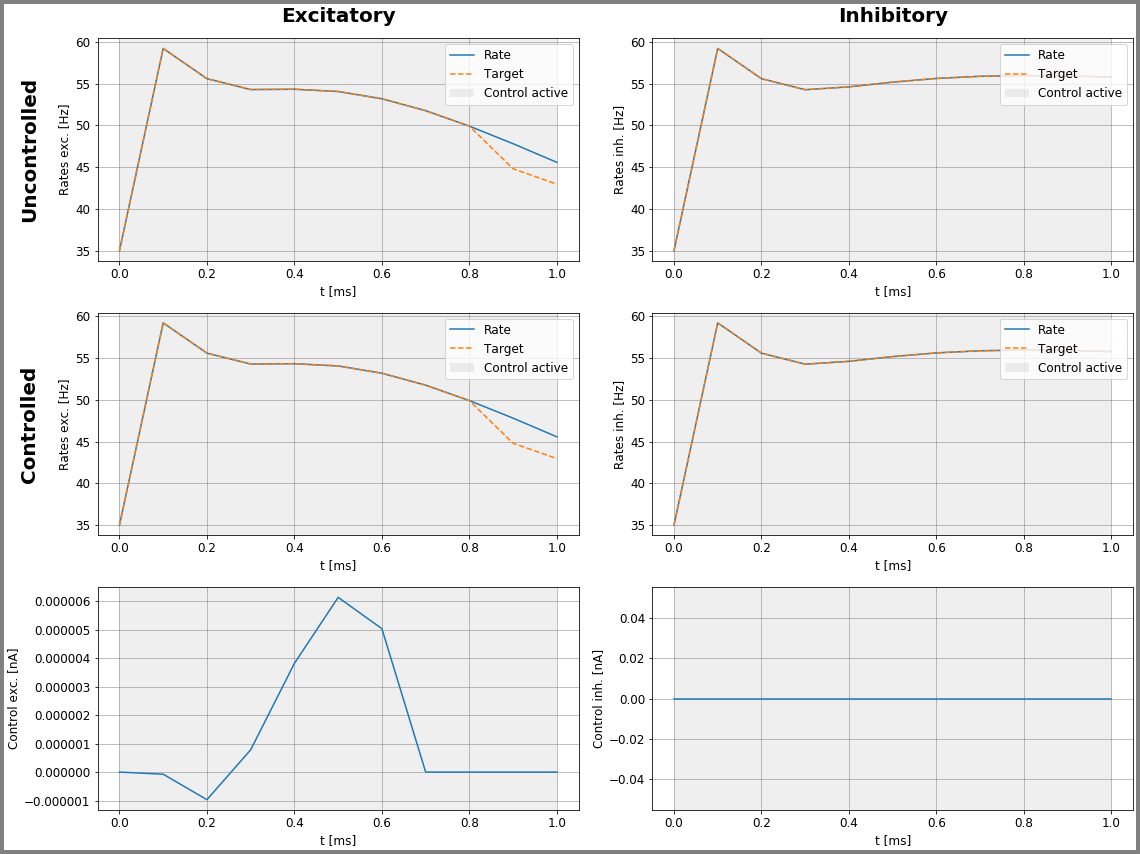

In [507]:
print(A1_bestControl[0,0,:])
plotFunc.plot_control(aln, A1_bestControl, dur, dur_pre, dur_post, initvars, target,
                      path, filename_ = 'a1_exc.pdf')

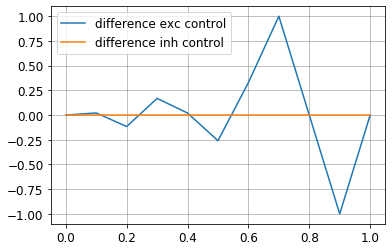

runtime =  22.674976700000116
Control difference =  0.2915434140474991


In [487]:
cDiff = control1 - A1_bestControl
plt.plot(aln.t, cDiff[0,0,:], label="difference exc control")
plt.plot(aln.t, cDiff[0,1,:], label="difference inh control")
plt.legend()
plt.show()

print("runtime = ", runtime[-1])
d_int = diff_control(cDiff)
print("Control difference = ", d_int)

[ 0.00000000e+00 -1.10740980e-07  3.90450853e-07 -5.70758250e-04
  8.99706861e-04  4.02199115e-07 -3.71519673e-07 -1.55168468e-07
 -1.72553209e-07  0.00000000e+00  0.00000000e+00]


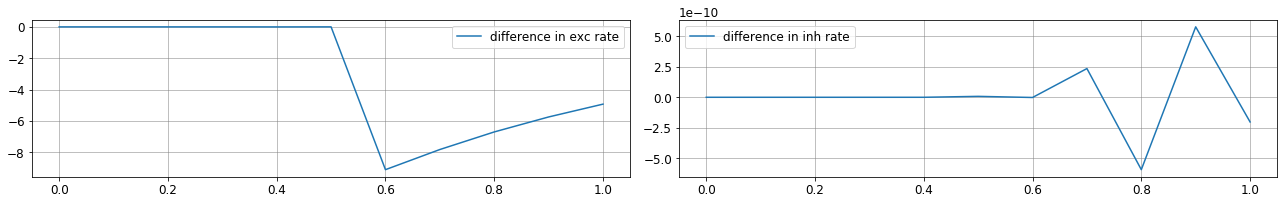

In [408]:
set_init(initvars)
aln.run(control=A1_bestControl)
rates3 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

diff1 = rates3 - rates2
plot_dif(diff1)
plt.savefig("diff1_exc.pdf")
print(A1_bestControl[0,0,:])


[ 0.00000000e+00 -1.10740980e-07  3.90450853e-07 -5.70763250e-04
  8.99716861e-04  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]


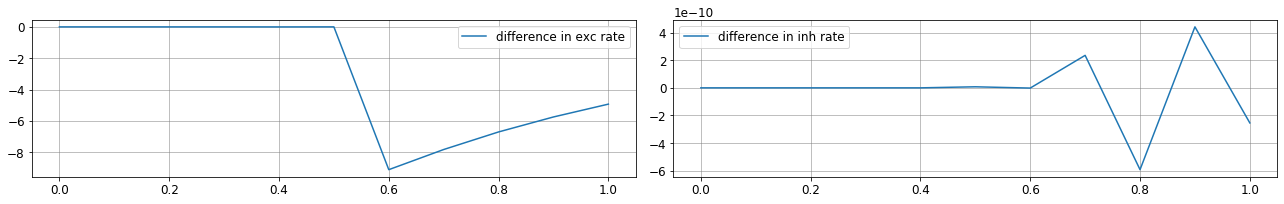

In [423]:
test_control = A1_bestControl.copy()
test_control[0,0,5:] = 0.
test_control[0,0,4] += 1e-8
test_control[0,0,3] -= 5.*1e-9

set_init(initvars)
aln.run(control=test_control)
rates3 = np.array( [aln.state["rates_exc"][0,:], aln.state["rates_inh"][0,:]] )

diff1 = rates3 - rates2
plot_dif(diff1)
plt.savefig("diff1_exc.pdf")
print(test_control[0,0,:])